# Assignment
## Customer Default Risk Prediction Using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("synthetic_dataset_10000x20.csv")

In [3]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


## Task 1 : Exploratory Data Analysis (EDA)

In [4]:
#Dataset shape
df.shape

(10000, 21)

In [5]:
#data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  str    
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  str    
 11  education            10000 non-null  str    
 12  marital_status       10000 non-null  str    
 13  region               10000 non-null  str    
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  int64  
 16

In [6]:
df.dtypes

customer_id                str
age                      int64
income                 float64
savings                float64
monthly_expenses       float64
num_dependents           int64
credit_score           float64
loan_amount            float64
loan_term_months         int64
employment_years       float64
home_ownership             str
education                  str
marital_status             str
region                     str
recent_default           int64
has_credit_card          int64
signup_date                str
signup_dayofweek         int64
debt_to_income         float64
sin_age                float64
target_default_risk      int64
dtype: object

In [7]:
#missing values
(df.isnull().sum()/len(df))*100

customer_id            0.00
age                    0.00
income                 3.18
savings                3.11
monthly_expenses       3.25
num_dependents         0.00
credit_score           3.26
loan_amount            0.00
loan_term_months       0.00
employment_years       0.00
home_ownership         0.00
education              0.00
marital_status         0.00
region                 0.00
recent_default         0.00
has_credit_card        0.00
signup_date            0.00
signup_dayofweek       0.00
debt_to_income         0.00
sin_age                0.00
target_default_risk    0.00
dtype: float64

In [8]:
#unique values
df['income'].value_counts()

income
21232.0    4
20702.0    4
25240.0    3
27931.0    3
23360.0    3
          ..
31124.0    1
61252.0    1
44507.0    1
20651.0    1
38273.0    1
Name: count, Length: 9107, dtype: int64

In [9]:
#unique values
df['income'].nunique()

9107

In [10]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


<Axes: xlabel='age', ylabel='Count'>

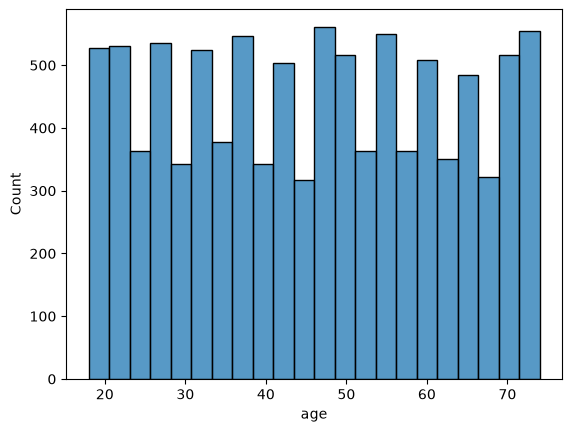

In [11]:
#Plot distributions of numeric features (histograms, boxplots).
sns.histplot(data=df,x='age')

<Axes: xlabel='income', ylabel='Count'>

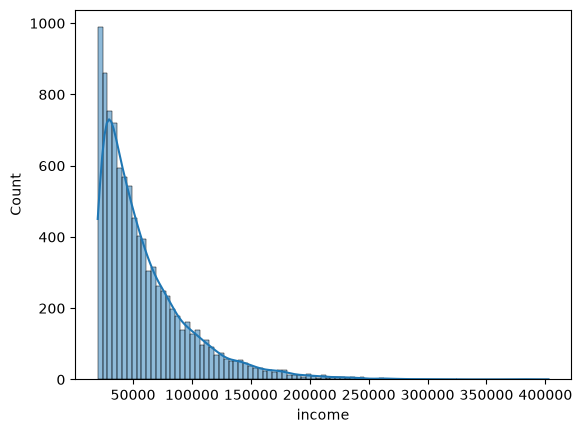

In [12]:
sns.histplot(data=df,x='income',kde=True)

<Axes: xlabel='savings', ylabel='Count'>

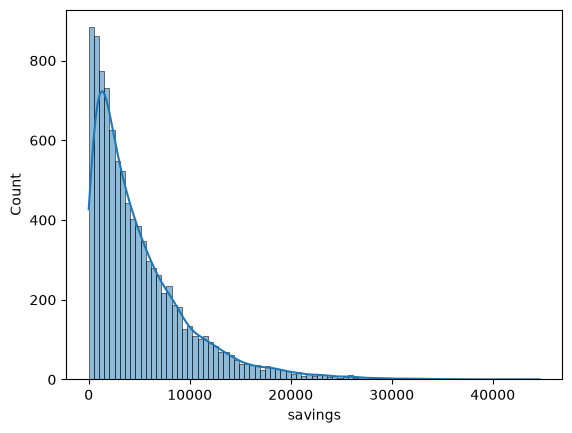

In [13]:
sns.histplot(data=df,x='savings',kde=True)

<Axes: xlabel='income'>

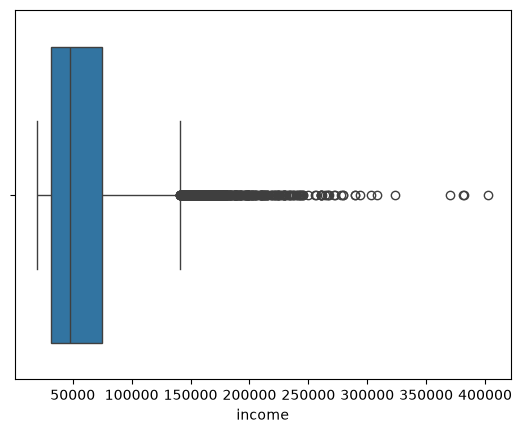

In [14]:
sns.boxplot(data=df,x="income")

<Axes: xlabel='education', ylabel='income'>

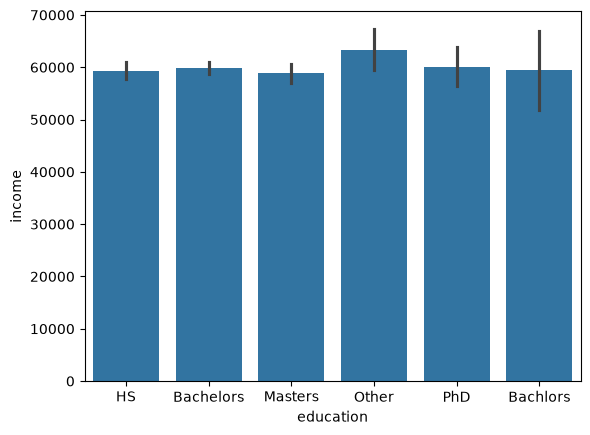

In [15]:
#Analyze categorical variables (bar charts, value counts).

sns.barplot(data=df,x="education",y="income")

<Axes: xlabel='region', ylabel='income'>

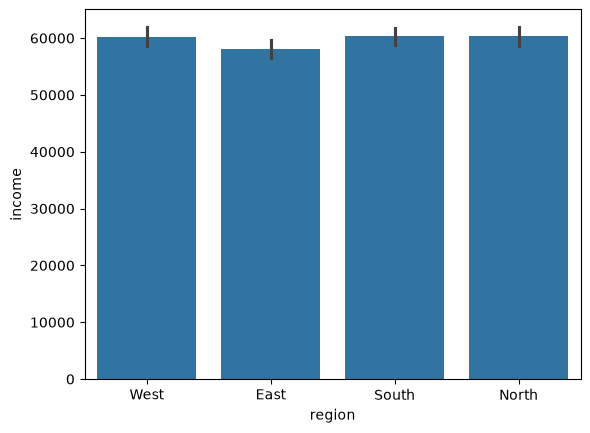

In [16]:
sns.barplot(data=df,x="region",y="income")

In [17]:
numerical_col=['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age']

In [18]:
#Detect outliers and discuss strategies to handle them.

for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(col, ":", len(outliers), "outliers")

age : 0 outliers
income : 479 outliers
savings : 472 outliers
monthly_expenses : 70 outliers
num_dependents : 24 outliers
credit_score : 62 outliers
loan_amount : 89 outliers
loan_term_months : 0 outliers
employment_years : 51 outliers
recent_default : 470 outliers
has_credit_card : 0 outliers
signup_dayofweek : 0 outliers
debt_to_income : 318 outliers
sin_age : 0 outliers


In [19]:
categorical_cols =['customer_id', 'home_ownership', 'education', 'marital_status',
       'region']

In [20]:
for col in categorical_cols[1:]:
    print(df[col].value_counts())
    print("\n")

home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64


education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64


marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64


region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64




In [21]:
#Explore correlations (heatmap, pairplot).
f = df.corr(numeric_only=True)

<Axes: >

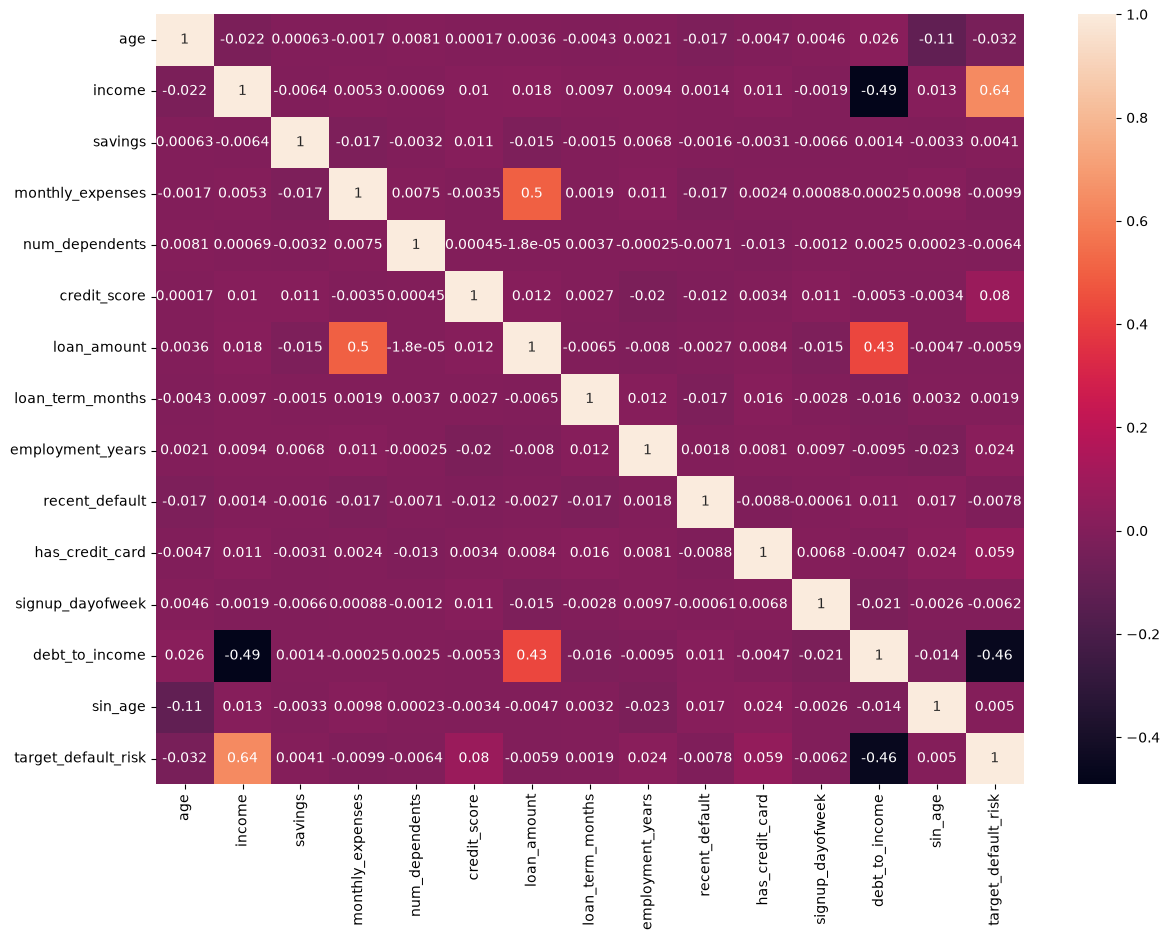

In [22]:
plt.figure(figsize=(14,10))
sns.heatmap(f,annot=True)


In [23]:
selected_col=numerical_col[0:6]

In [24]:
f = df[selected_col].corr()

<Axes: >

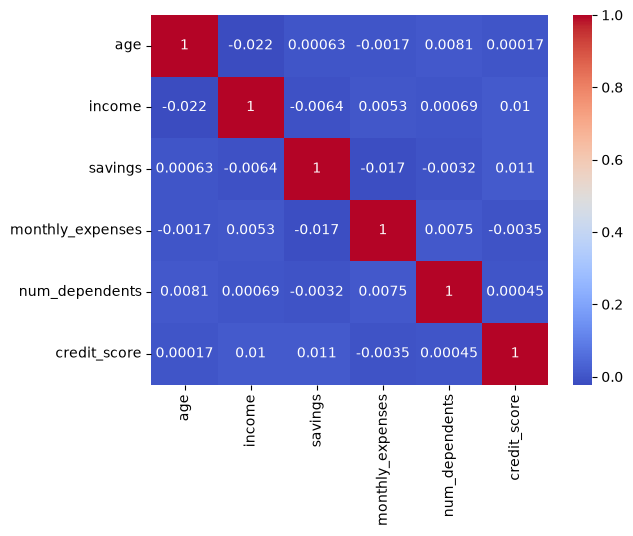

In [25]:
sns.heatmap(f,annot=True,cmap="coolwarm")

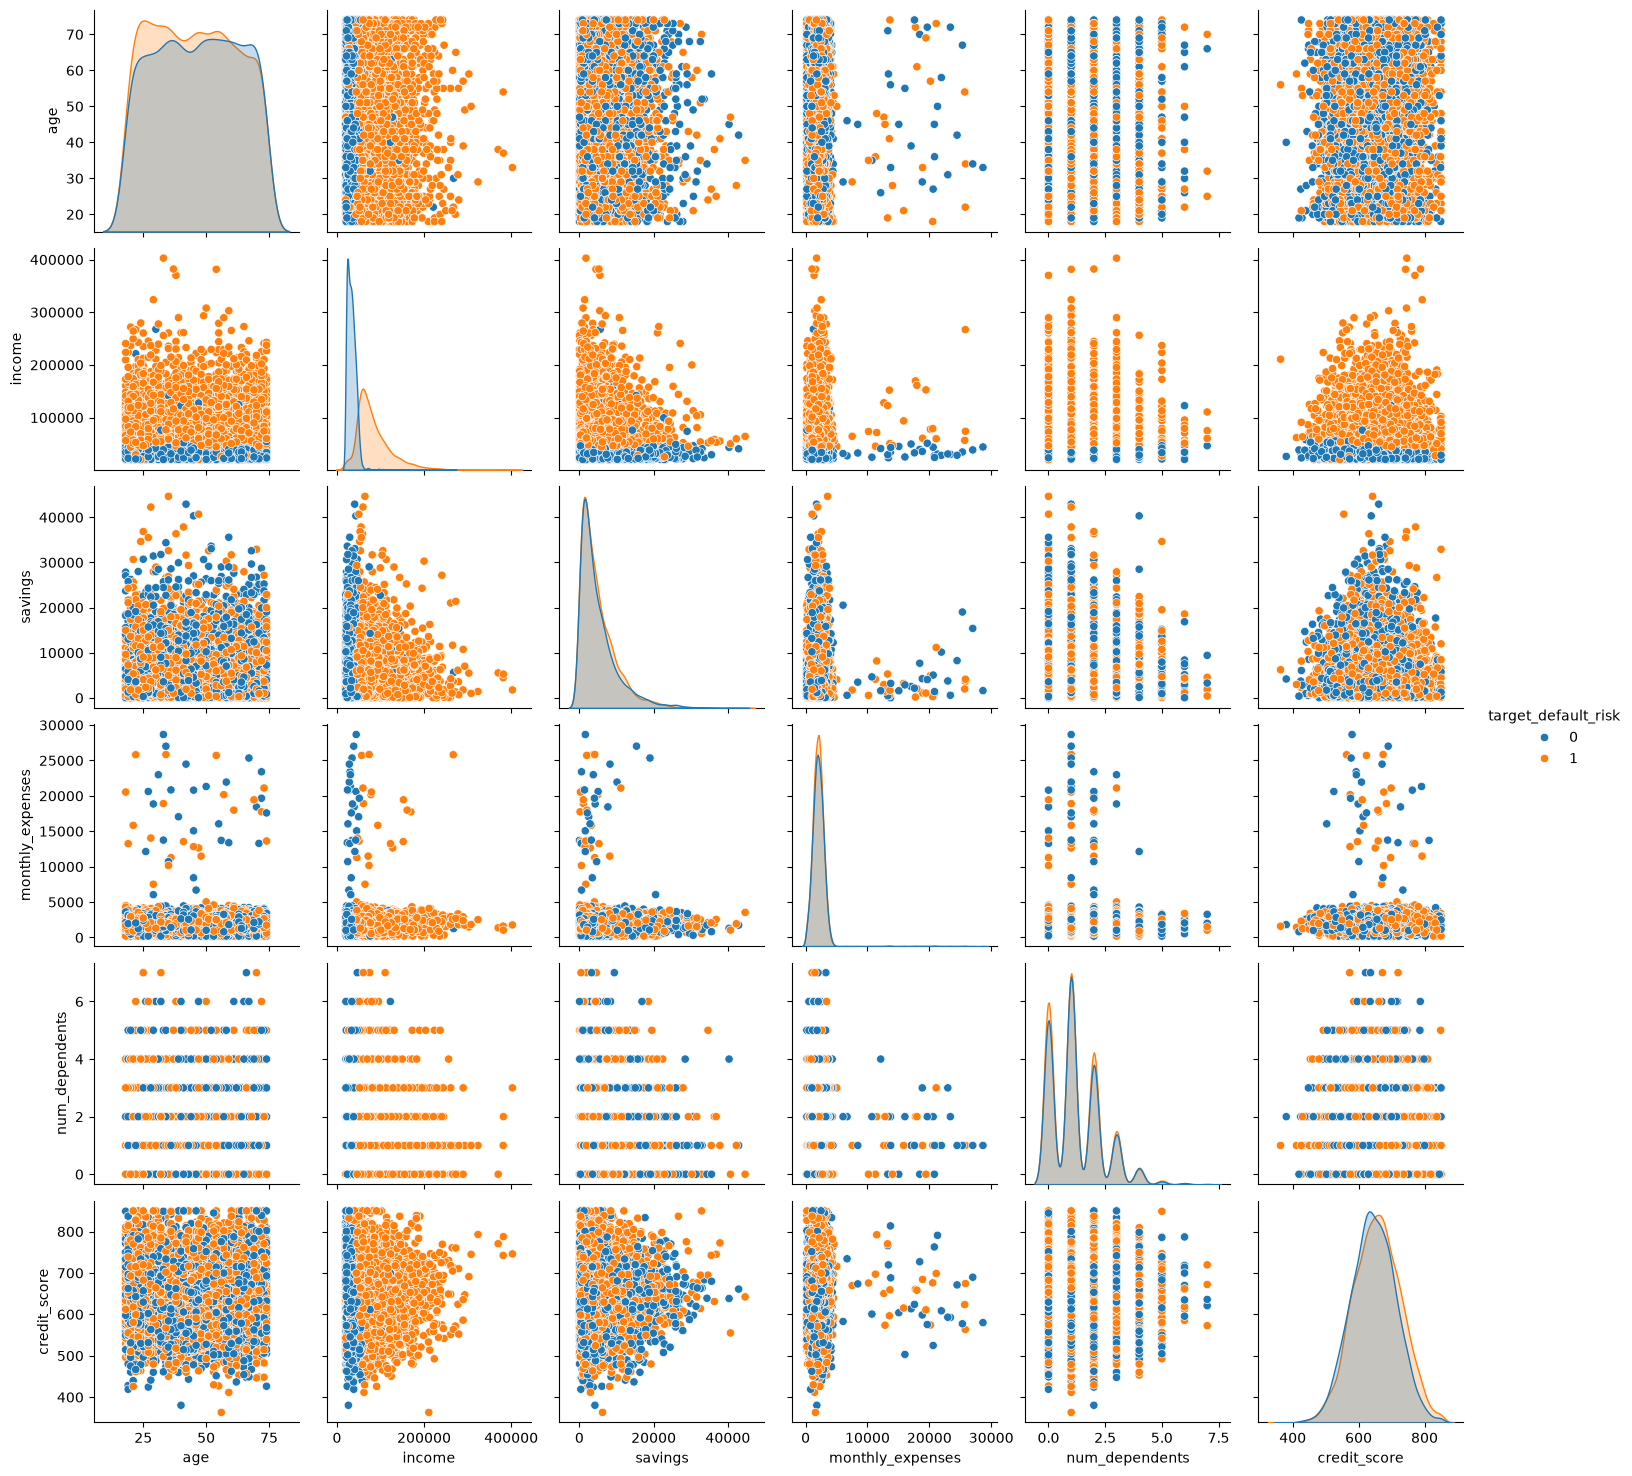

In [26]:
sns.pairplot(data=df,vars=[
    'age','income','savings',
    'monthly_expenses','num_dependents','credit_score'],
             hue="target_default_risk")

In [27]:
# Look at class balance in `target_default_risk`
df["target_default_risk"].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

<Axes: xlabel='target_default_risk', ylabel='count'>

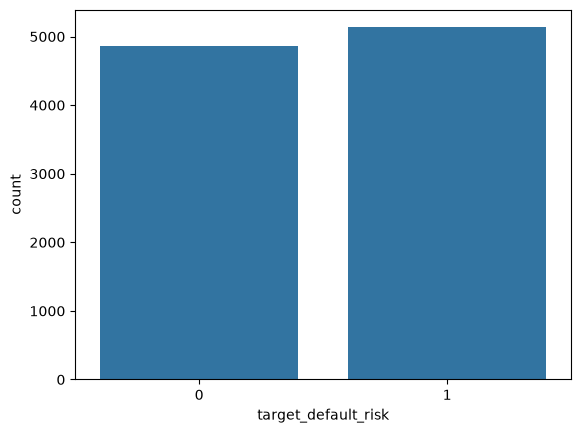

In [28]:
sns.countplot(data=df,x="target_default_risk")

## 2. Data Preprocessing

Missing values → Fix categories → Date transformation → Feature engineering → Outlier treatment → Encoding → Scaling → Train/Test Split

In [29]:
#handling missing values
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [30]:
#calculating the percentage for missing data
df.isnull().sum()/len(df)*100

customer_id            0.00
age                    0.00
income                 3.18
savings                3.11
monthly_expenses       3.25
num_dependents         0.00
credit_score           3.26
loan_amount            0.00
loan_term_months       0.00
employment_years       0.00
home_ownership         0.00
education              0.00
marital_status         0.00
region                 0.00
recent_default         0.00
has_credit_card        0.00
signup_date            0.00
signup_dayofweek       0.00
debt_to_income         0.00
sin_age                0.00
target_default_risk    0.00
dtype: float64

In [31]:
for col in numerical_col:
    df[col]=df[col].fillna(df[col].median())

In [32]:
df.isnull().sum()

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64

In [33]:
#categorical inconsistencies
for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

customer_id
CUST006253    1
CUST004685    1
CUST001732    1
CUST004743    1
CUST004522    1
             ..
CUST005735    1
CUST005192    1
CUST005391    1
CUST000861    1
CUST007271    1
Name: count, Length: 10000, dtype: int64


home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64


education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64


marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64


region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64




In [34]:
df['education']=df['education'].replace({
     "Bachlors": "Bachelors",
})

In [35]:
df["education"].value_counts()

education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64

In [36]:
for col in categorical_cols:
    df[col]=df[col].str.lower()

In [37]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

customer_id
cust006253    1
cust004685    1
cust001732    1
cust004743    1
cust004522    1
             ..
cust005735    1
cust005192    1
cust005391    1
cust000861    1
cust007271    1
Name: count, Length: 10000, dtype: int64


home_ownership
rent        4524
own         2526
mortgage    2498
other        452
Name: count, dtype: int64


education
bachelors    4530
hs           2546
masters      1962
other         500
phd           462
Name: count, dtype: int64


marital_status
single      4486
married     4002
divorced    1000
widowed      512
Name: count, dtype: int64


region
east     2553
south    2523
north    2479
west     2445
Name: count, dtype: int64




In [38]:
df.drop(columns=['customer_id'],errors="ignore",inplace=True)

In [39]:
#Create or transform features if useful (e.g., income per dependent, recency from `signup_date`).
df["income_per_dependent"] = (
    df["income"] / (df["num_dependents"] + 1)
)

In [40]:
df["signup_date"]=pd.to_datetime(df['signup_date'],errors='coerce')


In [41]:
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month
df["signup_day"] = df["signup_date"].dt.day
df["signup_dayofweek"] = df["signup_date"].dt.dayofweek

today=pd.Timestamp.today()

df["recency_days"] = (
    today - df["signup_date"]
).dt.days

df[["signup_date", "recency_days"]].head()

,signup_date,recency_days
0,2020-07-05,2268
1,2018-10-03,2909
2,2018-05-30,3035
3,2018-04-22,3073
4,2019-12-03,2483


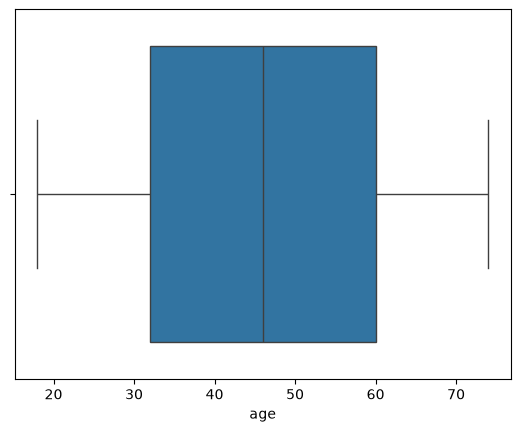

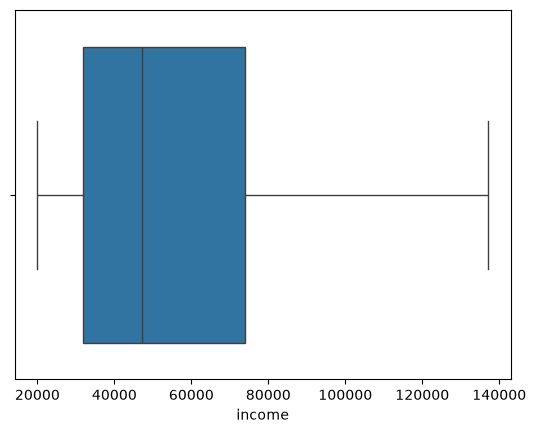

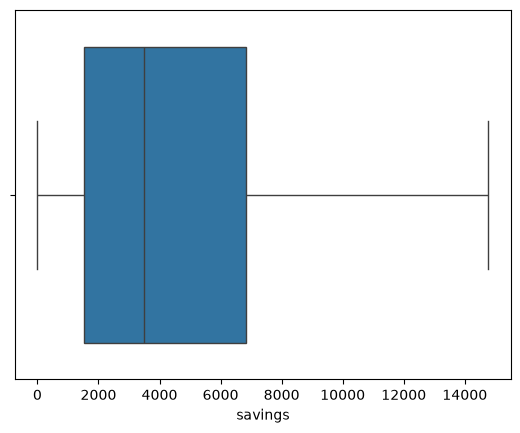

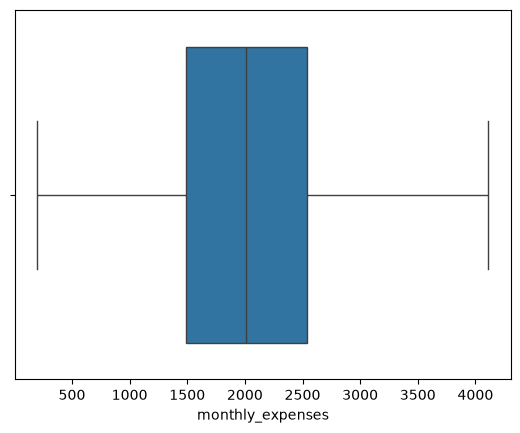

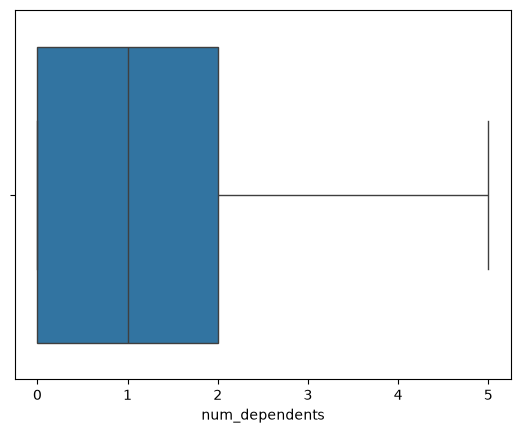

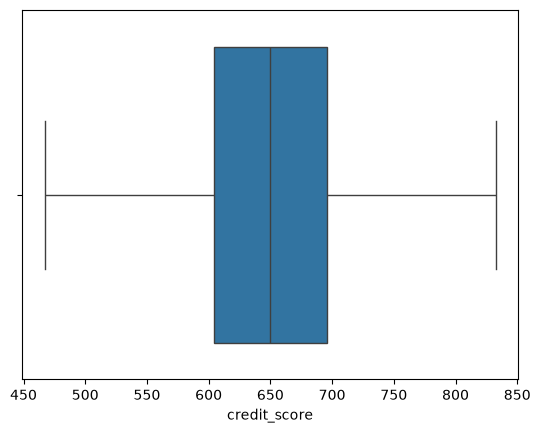

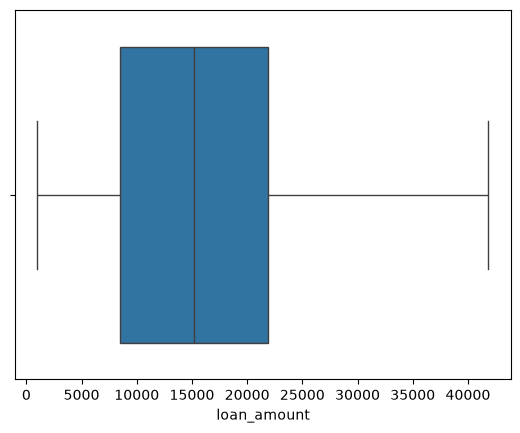

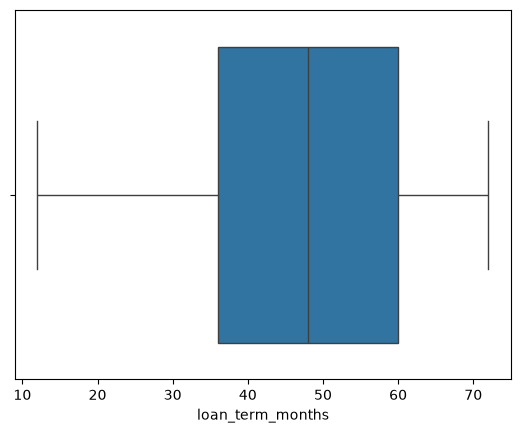

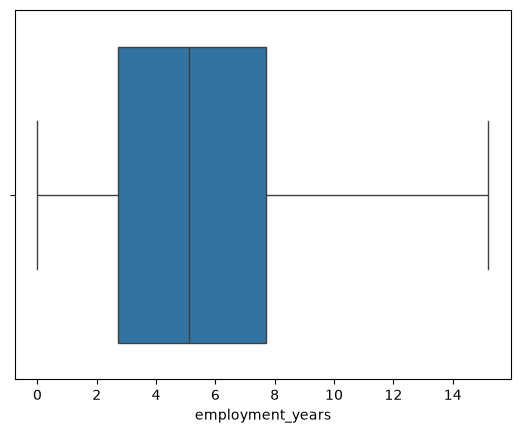

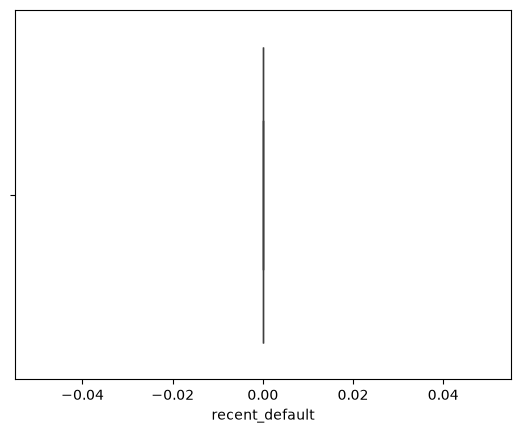

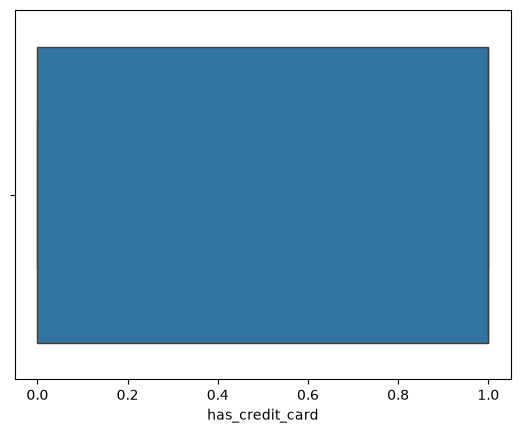

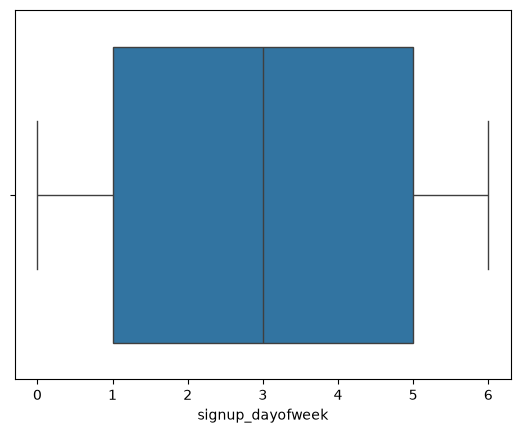

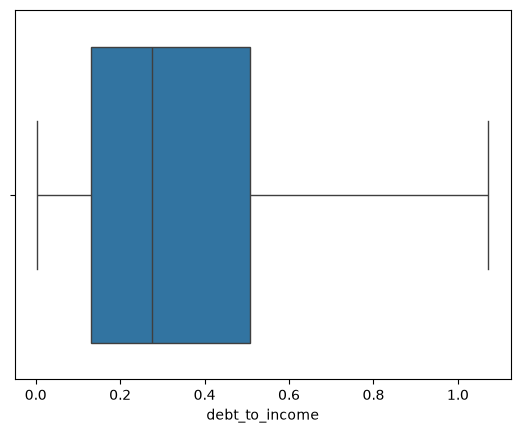

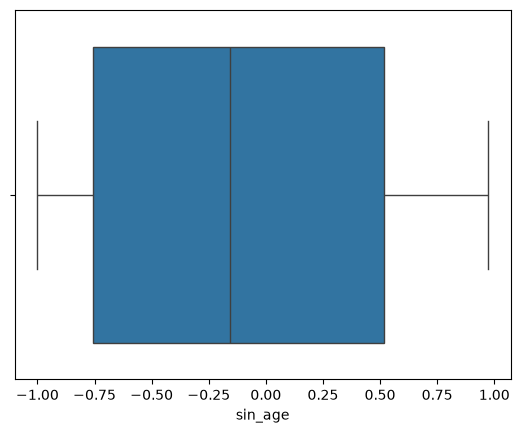

In [42]:
#Outlier treatment (winsorization, capping, or removal).
#capping

for col in numerical_col:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

for col in numerical_col:
    sns.boxplot(x=df[col])
    plt.show()

### Outlier Treatment

Outliers were identified using the IQR method.

Instead of removing the outliers, I used IQR-based capping. This preserves the observations while reducing the influence of extreme values.

The lower limit was calculated as:

Lower Limit = Q1 - 1.5 × IQR

The upper limit was calculated as:

Upper Limit = Q3 + 1.5 × IQR

Values below the lower limit were replaced with the lower limit, and values above the upper limit were replaced with the upper limit.

In [43]:
#Encode categorical variables (one-hot encoding / ordinal encoding).
categorical_cols

['customer_id', 'home_ownership', 'education', 'marital_status', 'region']

In [44]:
df.drop("signup_date", axis=1, inplace=True)

In [45]:
from sklearn.model_selection import train_test_split
x=df.drop("target_default_risk",axis=1)
y=df["target_default_risk"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [47]:
print(type(x_train))

<class 'pandas.DataFrame'>


In [48]:
#Transformation 
transformer=ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(sparse_output=False,drop='first'),
     ['home_ownership','education','marital_status','region'])
],remainder='passthrough')

In [49]:
x_train_encoded=transformer.fit_transform(x_train)
x_test_encoded=transformer.transform(x_test)

In [50]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

In [51]:
transformer.named_transformers_['tnf1'].get_feature_names_out()

array(['home_ownership_other', 'home_ownership_own',
       'home_ownership_rent', 'education_hs', 'education_masters',
       'education_other', 'education_phd', 'marital_status_married',
       'marital_status_single', 'marital_status_widowed', 'region_north',
       'region_south', 'region_west'], dtype=object)

In [52]:
#Scaling
from sklearn.preprocessing import StandardScaler
obj=StandardScaler()
obj.fit(x_train_encoded)
x_train_scaled=obj.transform(x_train_encoded)
x_test_scaled=obj.transform(x_test_encoded)

# Model Building

In [53]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [54]:
#1. Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [55]:
y_pred_log=model.predict(x_test_scaled)
print("Accuracy Score using Logistic Regression: ",accuracy_score(y_test,y_pred_log))
print("Precision using Logistic Regression: ",precision_score(y_test,y_pred_log))
print("Recall using Logistic Regression: ",recall_score(y_test,y_pred_log))
print("F1 score using Logistic Regression: ",f1_score(y_test,y_pred_log))
print("Confusion matrix using Logistic Regression:\n",confusion_matrix(y_test,y_pred_log))

Accuracy Score using Logistic Regression:  0.9385
Precision using Logistic Regression:  0.9611848825331971
Recall using Logistic Regression:  0.9171539961013645
F1 score using Logistic Regression:  0.9386533665835411
Confusion matrix using Logistic Regression:
 [[936  38]
 [ 85 941]]


In [56]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
y_pred_dtc=dtc.predict(x_test_scaled)
print("Accuracy Score using Decision Tree: ",accuracy_score(y_test,y_pred_dtc))
print("Precision using Decision Tree: ",precision_score(y_test,y_pred_dtc))
print("Recall using Decision Tree: ",recall_score(y_test,y_pred_dtc))
print("F1 score using Decision Tree: ",f1_score(y_test,y_pred_dtc))
print("Confusion matrix using Decision Tree:\n",confusion_matrix(y_test,y_pred_dtc))

Accuracy Score using Decision Tree:  0.9245
Precision using Decision Tree:  0.9301868239921337
Recall using Decision Tree:  0.9220272904483431
F1 score using Decision Tree:  0.9260890846793931
Confusion matrix using Decision Tree:
 [[903  71]
 [ 80 946]]


In [58]:
#Support Vector Machine
from sklearn.svm import SVC
supportVM=SVC()
supportVM.fit(x_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
y_pred_svm=supportVM.predict(x_test_scaled)
print("Accuracy Score using Support Vector Machine SVM: ",accuracy_score(y_test,y_pred_svm))
print("Precision using Support Vector Machine SVM: ",precision_score(y_test,y_pred_svm))
print("Recall using Support Vector Machine SVM: ",recall_score(y_test,y_pred_svm))
print("F1 score using Support Vector Machine SVM: ",f1_score(y_test,y_pred_svm))
print("Confusion matrix using Support Vector Machine SVM:\n",confusion_matrix(y_test,y_pred_svm))

Accuracy Score using Support Vector Machine SVM:  0.926
Precision using Support Vector Machine SVM:  0.9535123966942148
Recall using Support Vector Machine SVM:  0.8996101364522417
F1 score using Support Vector Machine SVM:  0.925777331995988
Confusion matrix using Support Vector Machine SVM:
 [[929  45]
 [103 923]]


In [60]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=10)
rf.fit(x_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [61]:
y_pred_rf=rf.predict(x_test_scaled)
print("Accuracy Score using Random Forest: ",accuracy_score(y_test,y_pred_rf))
print("Precision using Random Forest: ",precision_score(y_test,y_pred_rf))
print("Recall using Random Forest: ",recall_score(y_test,y_pred_rf))
print("F1 score using Random Forest: ",f1_score(y_test,y_pred_rf))
print("Confusion matrix using Random Forest:\n",confusion_matrix(y_test,y_pred_rf))

Accuracy Score using Random Forest:  0.9275
Precision using Random Forest:  0.9564766839378238
Recall using Random Forest:  0.8996101364522417
F1 score using Random Forest:  0.9271722752385736
Confusion matrix using Random Forest:
 [[932  42]
 [103 923]]


In [62]:
#XGBBOOST
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train_scaled,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [63]:
y_pred_xgb=xgb.predict(x_test_scaled)
print("Accuracy Score using XGBoost: ",accuracy_score(y_test,y_pred_xgb))
print("Precision using XGBoost: ",precision_score(y_test,y_pred_xgb))
print("Recall using XGBoost: ",recall_score(y_test,y_pred_xgb))
print("F1 score using XGBoost: ",f1_score(y_test,y_pred_xgb))
print("Confusion matrix using XGBoost: \n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score using XGBoost:  0.9555
Precision using XGBoost:  0.9579667644183774
Recall using XGBoost:  0.9551656920077972
F1 score using XGBoost:  0.956564177647633
Confusion matrix using XGBoost: 
 [[931  43]
 [ 46 980]]


# Hyperparameter Tuning

## Random Forest Tunning

In [64]:
#tuning Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [70]:
rf_tunned=RandomForestClassifier(random_state=42)
param_grid_rf={
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_rf=GridSearchCV(
    rf_tunned,
    param_grid_rf,
    cv=5,
    n_jobs=-1
)
grid_rf.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [67]:
print("Best Parameters: ",grid_rf.best_params_)
print("Best Cross-Validation Accuracy: ",grid_rf.best_score_)
print()

Best Parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy:  0.92675



In [69]:
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(x_test_scaled)

print("Tuned Random Forest Accuracy:",accuracy_score(y_test, y_pred_rf_tuned))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Tuned Random Forest Accuracy: 0.939
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       974
           1       0.96      0.92      0.94      1026

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



## XGB Tunning

In [72]:
from sklearn.model_selection import RandomizedSearchCV

xgb_tunned=XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid_xgb={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
random_xgb=RandomizedSearchCV(
    xgb_tunned,
    param_distributions=param_grid_xgb,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_xgb.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instanc

In [73]:
print("Best Parameters:",random_xgb.best_params_)

print("Best Cross-Validation Accuracy:",random_xgb.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best Cross-Validation Accuracy: 0.9501249999999999


In [81]:
best_xgb=random_xgb.best_estimator_
y_pred_xgb_tunned=best_xgb.predict(x_test_scaled)
print("Tuned XGBoost Accuracy:",accuracy_score(y_test, y_pred_xgb_tunned))
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_tunned))

Tuned XGBoost Accuracy: 0.957
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       974
           1       0.97      0.95      0.96      1026

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



##  Hyperparameter Tuning

Hyperparameter tuning was performed to find better parameter combinations for the Random Forest and XGBoost models.

Random Forest was tuned using GridSearchCV with 5-fold cross-validation. The parameters considered were n_estimators, max_depth, min_samples_split, and min_samples_leaf.

XGBoost was tuned using RandomizedSearchCV with 5-fold cross-validation. The parameters considered were n_estimators, max_depth, learning_rate, subsample, and colsample_bytree.

The tuned models were evaluated on the same test dataset used for the baseline models. Their accuracy, precision, recall, and F1-score were compared with the baseline models to determine the effect of hyperparameter tuning.

# Comparsion of baseline and Hyperparameter tunning

In [82]:
rf_baseline = accuracy_score(y_test, y_pred_rf)
rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

xgb_baseline = accuracy_score(y_test, y_pred_xgb)
xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)

print("Random Forest")
print("Baseline Accuracy:", rf_baseline)
print("Tuned Accuracy:", rf_tuned)

print("\nXGBoost")
print("Baseline Accuracy:", xgb_baseline)
print("Tuned Accuracy:", xgb_tuned)

Random Forest
Baseline Accuracy: 0.9275
Tuned Accuracy: 0.939

XGBoost
Baseline Accuracy: 0.9555
Tuned Accuracy: 0.957
